In [1]:
print("Hello World!")

Hello World!


In [2]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
sb.set()


In [3]:
df= pd.read_csv("/content/car_Dekho_DA.csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [6]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [7]:
df.isnull().sum(axis=1)

,0
0,0
1,0
2,0
3,0
4,0
...,...
296,0
297,0
298,0
299,0


In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
aaa=df.describe()
type(aaa)

pandas.core.frame.DataFrame

In [10]:
df.Car_Name.value_counts()

,count
Car_Name,
city,26
corolla altis,16
verna,14
fortuner,11
brio,10
...,...
Honda Activa 125,1
Hero Hunk,1
Hero Ignitor Disc,1


In [11]:
df.Transmission.value_counts()

,count
Transmission,
Manual,261
Automatic,40


In [12]:
df.Fuel_Type.value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


r


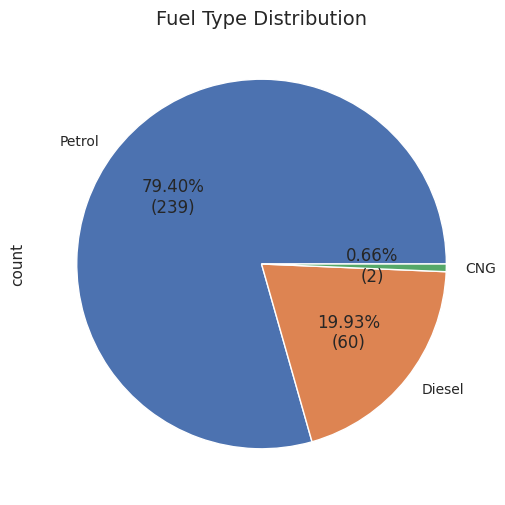

In [26]:
total_counts = df.Fuel_Type.value_counts().sum()
df.Fuel_Type.value_counts().plot.pie(

    autopct=lambda pct: f'{pct:.2f}%\n({int(round(pct * total_counts / 100.0))})',
    figsize=(6, 6),
    title="Fuel Type Distribution"
)
print((df.Fuel_Type[3][3]))

In [14]:
1

1

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/agents/output/01_overview_dashboard.png'

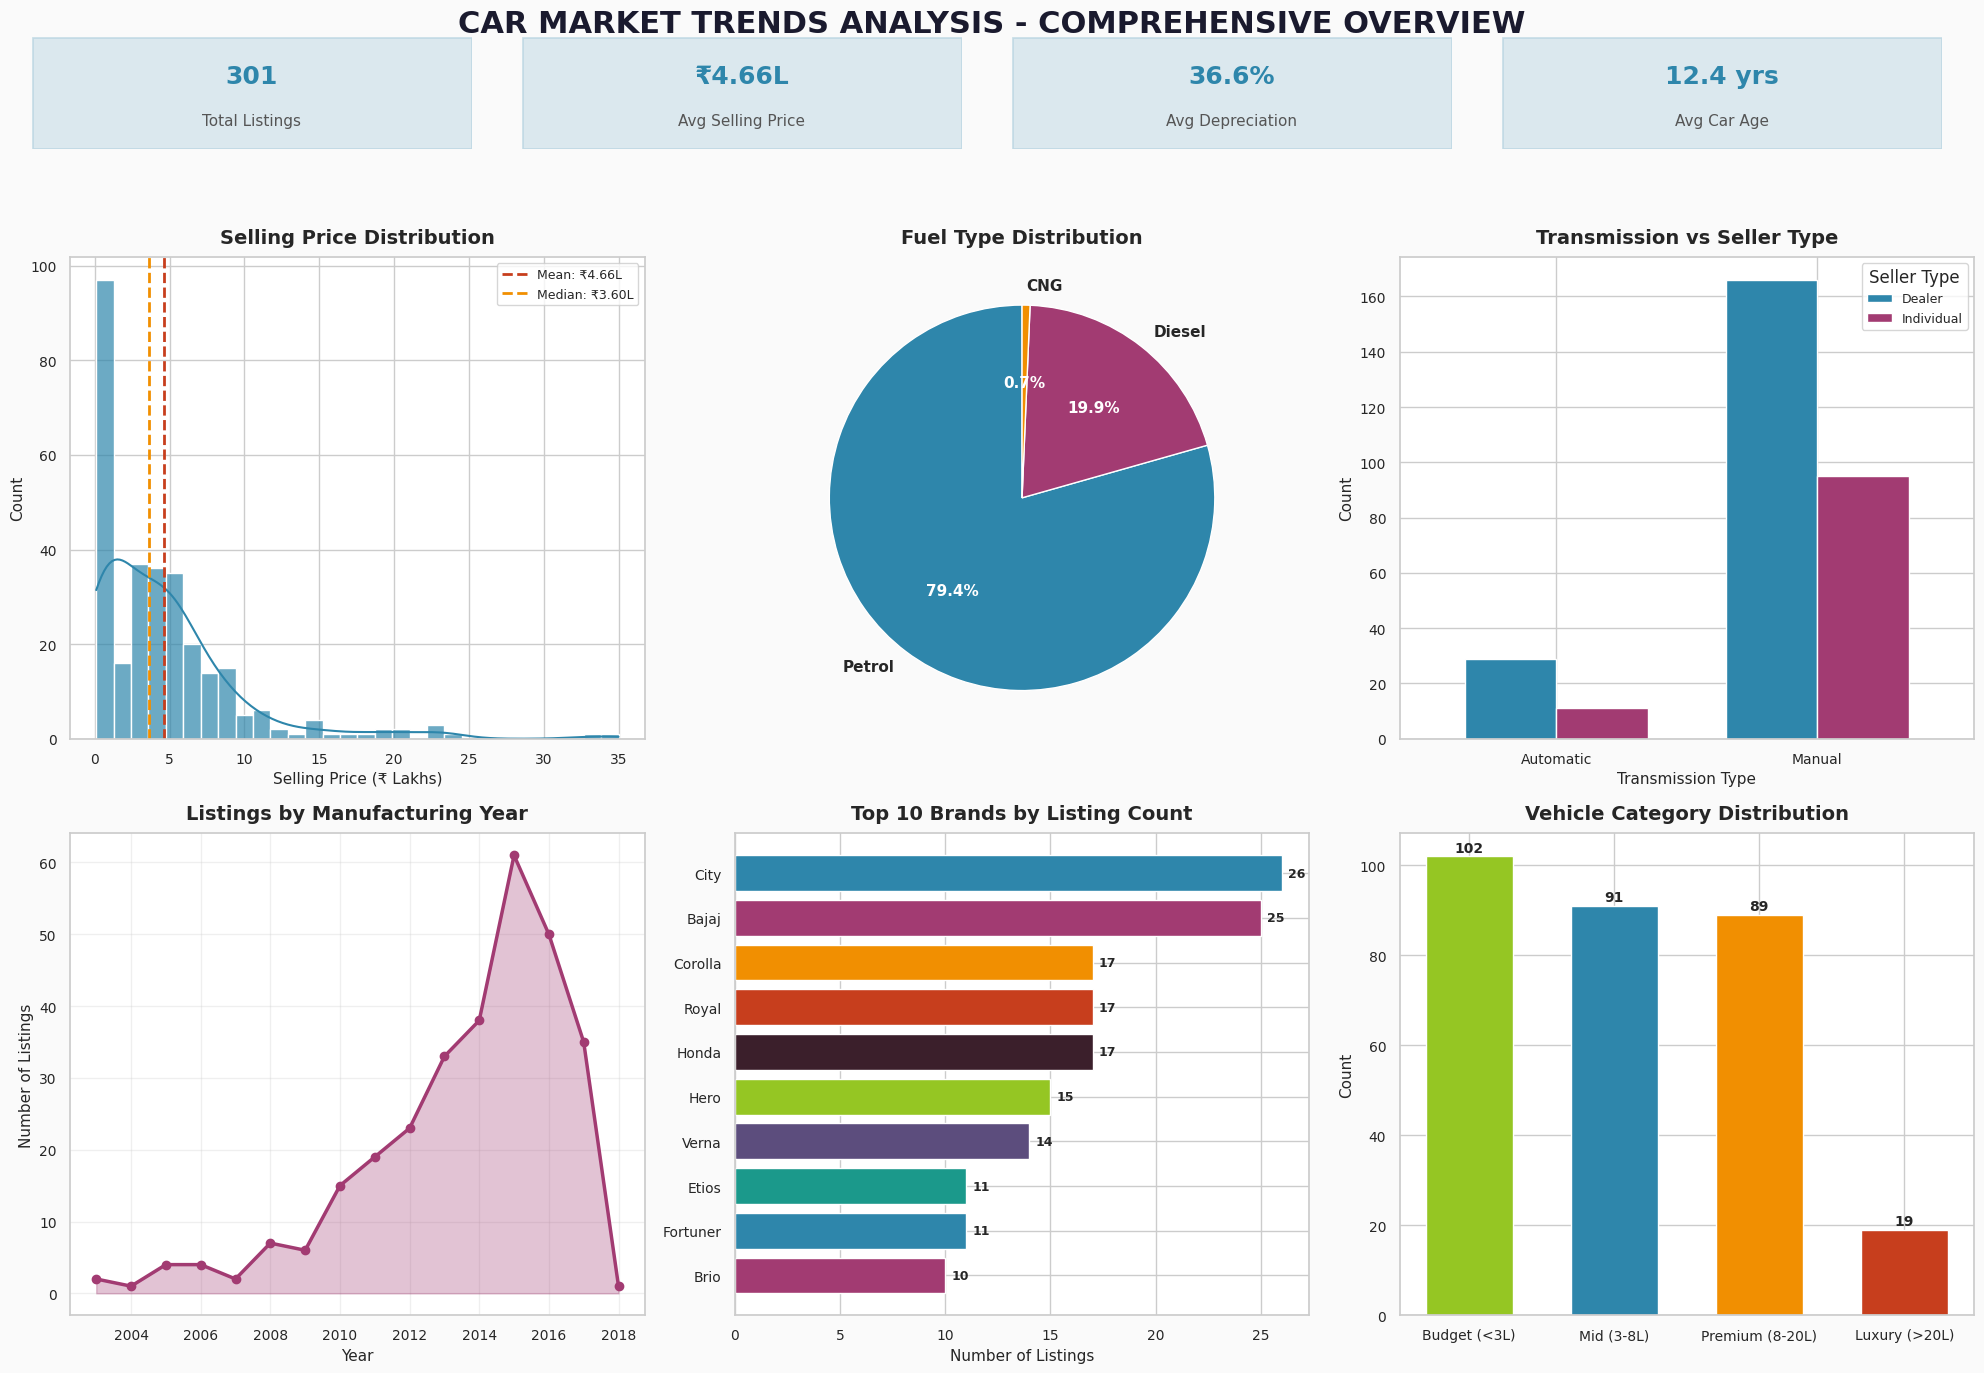

In [16]:


import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')




# Feature Engiiineeriing...

df['Car_Age'] = 2026 - df['Year']
df['Depreciation_Rate'] = ((df['Present_Price'] - df['Selling_Price']) / df['Present_Price']) * 100
df['Price_Drop'] = df['Present_Price'] - df['Selling_Price']
df['Brand'] = df['Car_Name'].apply(lambda x: x.split()[0].lower())

# Categorize by vehicle type based on price
df['Vehicle_Category'] = pd.cut(df['Present_Price'],
                                 bins=[0, 3, 8, 20, 100],
                                 labels=['Budget (<3L)', 'Mid (3-8L)', 'Premium (8-20L)', 'Luxury (>20L)'])


# style SETUP

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# color palet...
palette_main = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#95C623', '#5C4D7D', '#1B998B']
palette_fuel = {'Petrol': '#2E86AB', 'Diesel': '#A23B72', 'CNG': '#F18F01'}
palette_seller = {'Dealer': '#2E86AB', 'Individual': '#A23B72'}
palette_trans = {'Manual': '#2E86AB', 'Automatic': '#A23B72'}


# CHART 1: COMPREHENSIVE OVERVIEW DASHBOARD..

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#FAFAFA')

# Title hehehe
fig.suptitle('CAR MARKET TRENDS ANALYSIS - COMPREHENSIVE OVERVIEW',
             fontsize=22, fontweight='bold', y=0.98, color='#1a1a2e')

# KPI Cards
kpi_data = [
    ('Total Listings', f"{len(df):,}", '#2E86AB'),
    ('Avg Selling Price', f"₹{df['Selling_Price'].mean():.2f}L", '#2E86AB'),
    ('Avg Depreciation', f"{df['Depreciation_Rate'].mean():.1f}%", '#2E86AB'),
    ('Avg Car Age', f"{df['Car_Age'].mean():.1f} yrs", '#2E86AB'),
]

for i, (label, value, color) in enumerate(kpi_data):
    ax = fig.add_axes([0.02 + i*0.245, 0.88, 0.22, 0.08])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    rect = Rectangle((0, 0), 1, 1, facecolor=color, alpha=0.15, edgecolor=color, linewidth=2,
                      transform=ax.transAxes, zorder=1)
    ax.add_patch(rect)
    ax.text(0.5, 0.65, value, ha='center', va='center', fontsize=18, fontweight='bold',
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=11, color='#555',
            transform=ax.transAxes)

# 1. Distribution of selling Price
ax1 = fig.add_subplot(2, 3, 1)
sns.histplot(df['Selling_Price'], kde=True, color='#2E86AB', bins=30, ax=ax1, alpha=0.7)
ax1.axvline(df['Selling_Price'].mean(), color='#C73E1D', linestyle='--', linewidth=2, label=f'Mean: ₹{df["Selling_Price"].mean():.2f}L')
ax1.axvline(df['Selling_Price'].median(), color='#F18F01', linestyle='--', linewidth=2, label=f'Median: ₹{df["Selling_Price"].median():.2f}L')
ax1.set_title('Selling Price Distribution', fontweight='bold', pad=10)
ax1.set_xlabel('Selling Price (₹ Lakhs)')
ax1.set_ylabel('Count')
ax1.legend(fontsize=9)

# 2. Fuel Type distribution
ax2 = fig.add_subplot(2, 3, 2)
fuel_counts = df['Fuel_Type'].value_counts()
colors_fuel = [palette_fuel.get(f, '#95C623') for f in fuel_counts.index]
wedges, texts, autotexts = ax2.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.1f%%',
                                     colors=colors_fuel, startangle=90,
                                     textprops={'fontsize': 11, 'fontweight': 'bold'})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax2.set_title('Fuel Type Distribution', fontweight='bold', pad=10)

# 3. Transmission & seller Type
ax3 = fig.add_subplot(2, 3, 3)
trans_seller = pd.crosstab(df['Transmission'], df['Seller_Type'])
trans_seller.plot(kind='bar', ax=ax3, color=['#2E86AB', '#A23B72'], width=0.7, edgecolor='white')
ax3.set_title('Transmission vs Seller Type', fontweight='bold', pad=10)
ax3.set_xlabel('Transmission Type')
ax3.set_ylabel('Count')
ax3.legend(title='Seller Type', fontsize=9)
ax3.tick_params(axis='x', rotation=0)

# 4. Year-wise Listing Count
ax4 = fig.add_subplot(2, 3, 4)
year_counts = df['Year'].value_counts().sort_index()
ax4.fill_between(year_counts.index, year_counts.values, alpha=0.3, color='#A23B72')
ax4.plot(year_counts.index, year_counts.values, marker='o', color='#A23B72', linewidth=2.5, markersize=6)
ax4.set_title('Listings by Manufacturing Year', fontweight='bold', pad=10)
ax4.set_xlabel('Year')
ax4.set_ylabel('Number of Listings')
ax4.grid(True, alpha=0.3)

# 5. Top 10 Brands by Count
ax5 = fig.add_subplot(2, 3, 5)
top_brands = df['Brand'].value_counts().head(10)
bars = ax5.barh(range(len(top_brands)), top_brands.values, color=palette_main[:len(top_brands)], edgecolor='white')
ax5.set_yticks(range(len(top_brands)))
ax5.set_yticklabels(top_brands.index.str.title(), fontsize=10)
ax5.invert_yaxis()
ax5.set_title('Top 10 Brands by Listing Count', fontweight='bold', pad=10)
ax5.set_xlabel('Number of Listings')
for i, (bar, val) in enumerate(zip(bars, top_brands.values)):
    ax5.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9, fontweight='bold')

# 6. Vehicle Category Distribution
ax6 = fig.add_subplot(2, 3, 6)
cat_counts = df['Vehicle_Category'].value_counts()
colors_cat = ['#95C623', '#2E86AB', '#F18F01', '#C73E1D']
bars = ax6.bar(range(len(cat_counts)), cat_counts.values, color=colors_cat[:len(cat_counts)], edgecolor='white', width=0.6)
ax6.set_xticks(range(len(cat_counts)))
ax6.set_xticklabels(cat_counts.index, fontsize=10)
ax6.set_title('Vehicle Category Distribution', fontweight='bold', pad=10)
ax6.set_ylabel('Count')
for bar, val in zip(bars, cat_counts.values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.87])
plt.savefig('/mnt/agents/output/01_overview_dashboard.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Chart 1 saved: Overview Dashboard")


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/agents/output/03_price_by_categories.png'

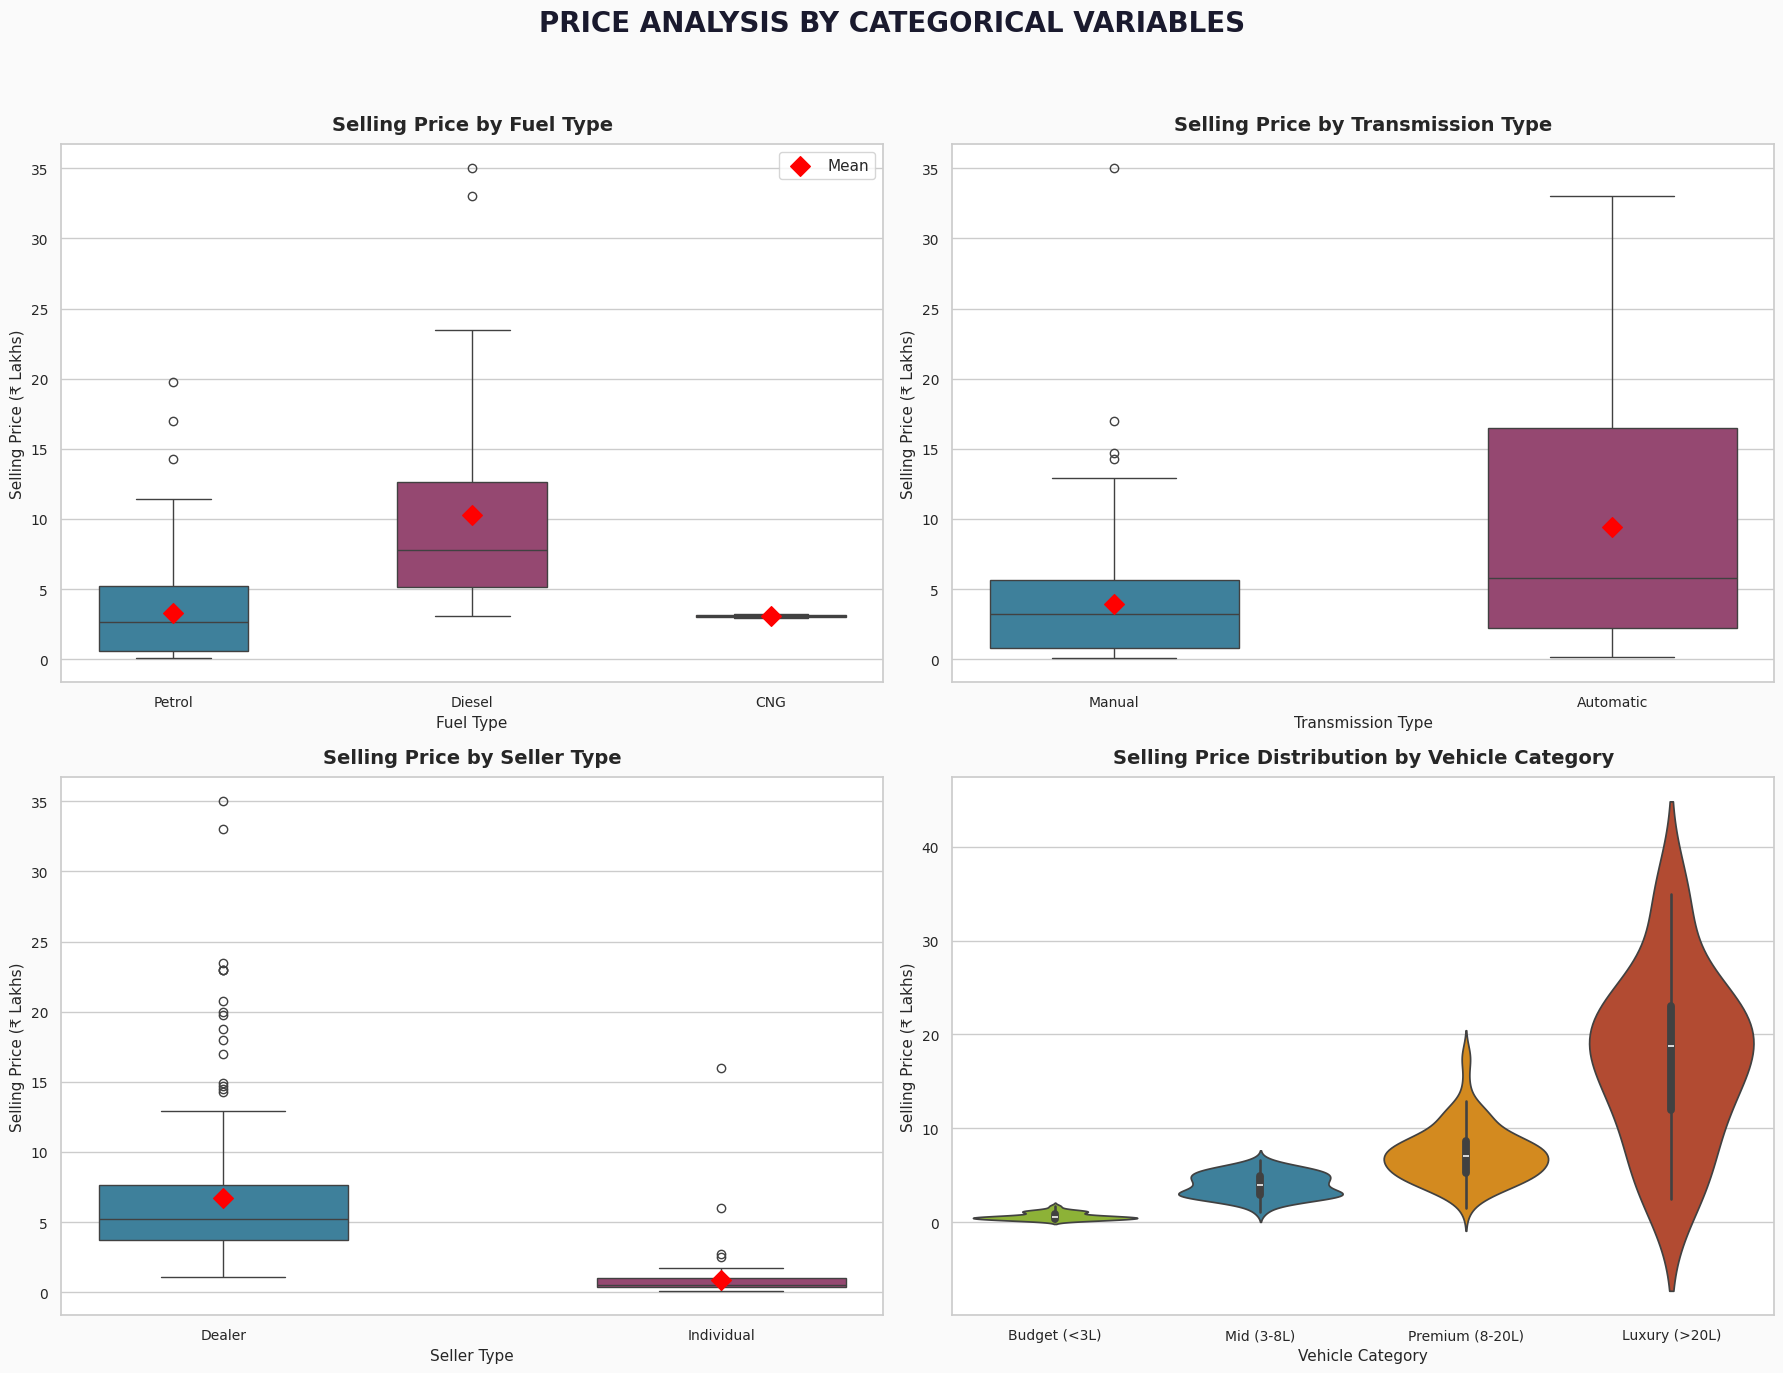

In [17]:


# CHART: PRICE ANALYSIS BY CATEGORICAL VARIABLES

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('PRICE ANALYSIS BY CATEGORICAL VARIABLES', fontsize=20, fontweight='bold', y=0.98, color='#1a1a2e')

# 1. Box Plot - Selling Price by Fuel Type
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', palette=palette_fuel, ax=axes[0,0], width=0.5)
axes[0,0].set_title('Selling Price by Fuel Type', fontweight='bold', pad=10)
axes[0,0].set_xlabel('Fuel Type')
axes[0,0].set_ylabel('Selling Price (₹ Lakhs)')
# Add mean markers
for i, fuel in enumerate(df['Fuel_Type'].unique()):
    mean_val = df[df['Fuel_Type'] == fuel]['Selling_Price'].mean()
    axes[0,0].scatter(i, mean_val, color='red', s=100, marker='D', zorder=5, label='Mean' if i==0 else '')
axes[0,0].legend()

# 2. Box Plot - Selling Price by Transmission
sns.boxplot(data=df, x='Transmission', y='Selling_Price', palette=palette_trans, ax=axes[0,1], width=0.5)
axes[0,1].set_title('Selling Price by Transmission Type', fontweight='bold', pad=10)
axes[0,1].set_xlabel('Transmission Type')
axes[0,1].set_ylabel('Selling Price (₹ Lakhs)')
for i, trans in enumerate(df['Transmission'].unique()):
    mean_val = df[df['Transmission'] == trans]['Selling_Price'].mean()
    axes[0,1].scatter(i, mean_val, color='red', s=100, marker='D', zorder=5)

# 3. Box Plot - Selling Price by Seller Type
sns.boxplot(data=df, x='Seller_Type', y='Selling_Price', palette=palette_seller, ax=axes[1,0], width=0.5)
axes[1,0].set_title('Selling Price by Seller Type', fontweight='bold', pad=10)
axes[1,0].set_xlabel('Seller Type')
axes[1,0].set_ylabel('Selling Price (₹ Lakhs)')
for i, seller in enumerate(df['Seller_Type'].unique()):
    mean_val = df[df['Seller_Type'] == seller]['Selling_Price'].mean()
    axes[1,0].scatter(i, mean_val, color='red', s=100, marker='D', zorder=5)

# 4. Violin Plot - Selling Price by Vehicle Category
sns.violinplot(data=df, x='Vehicle_Category', y='Selling_Price', palette=['#95C623', '#2E86AB', '#F18F01', '#C73E1D'],
               ax=axes[1,1], inner='box')
axes[1,1].set_title('Selling Price Distribution by Vehicle Category', fontweight='bold', pad=10)
axes[1,1].set_xlabel('Vehicle Category')
axes[1,1].set_ylabel('Selling Price (₹ Lakhs)')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('/mnt/agents/output/03_price_by_categories.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Chart saved: Price by Categories")


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/agents/output/05_top_models_analysis.png'

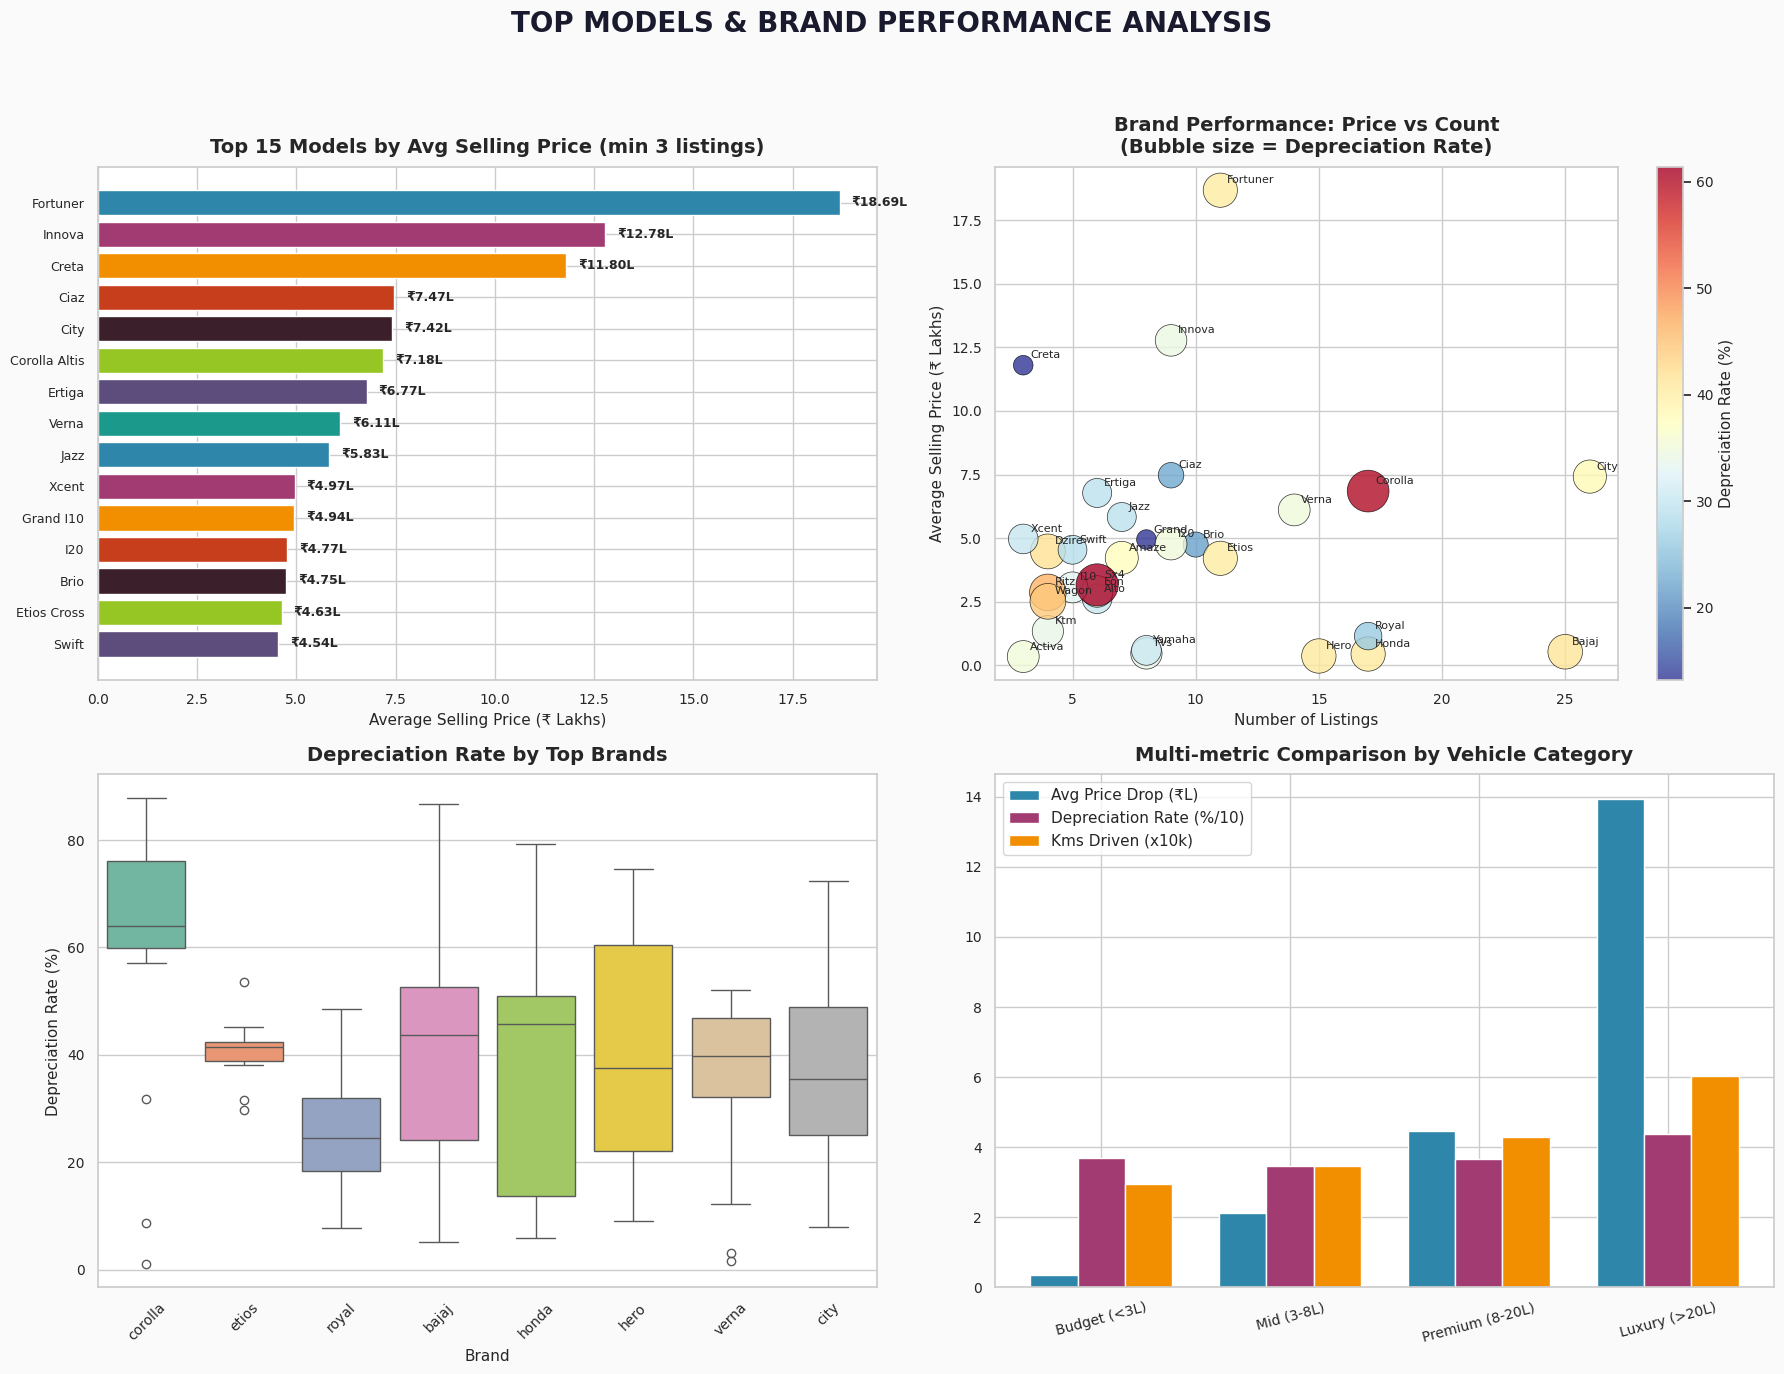

In [18]:


# CHART: TOP MODELS & BRAND PERFORMANCE ANALYSIS

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('TOP MODELS & BRAND PERFORMANCE ANALYSIS', fontsize=20, fontweight='bold', y=0.98, color='#1a1a2e')

# 1. Top 15 Models by Average Selling Price
top_models = df.groupby('Car_Name').agg({'Selling_Price': 'mean', 'Car_Name': 'count'}).rename(columns={'Car_Name': 'Count'})
top_models = top_models[top_models['Count'] >= 3].sort_values('Selling_Price', ascending=False).head(15)
bars = axes[0,0].barh(range(len(top_models)), top_models['Selling_Price'], color=palette_main[:len(top_models)], edgecolor='white')
axes[0,0].set_yticks(range(len(top_models)))
axes[0,0].set_yticklabels([m.title() for m in top_models.index], fontsize=9)
axes[0,0].invert_yaxis()
axes[0,0].set_title('Top 15 Models by Avg Selling Price (min 3 listings)', fontweight='bold', pad=10)
axes[0,0].set_xlabel('Average Selling Price (₹ Lakhs)')
for i, (bar, val) in enumerate(zip(bars, top_models['Selling_Price'])):
    axes[0,0].text(val + 0.3, bar.get_y() + bar.get_height()/2, f'₹{val:.2f}L', va='center', fontsize=9, fontweight='bold')

# 2. Top Brands: Avg Price vs Count (Bubble Chart)
brand_stats = df.groupby('Brand').agg({'Selling_Price': 'mean', 'Brand': 'count', 'Depreciation_Rate': 'mean'}).rename(columns={'Brand': 'Count'})
brand_stats = brand_stats[brand_stats['Count'] >= 3]
scatter = axes[0,1].scatter(brand_stats['Count'], brand_stats['Selling_Price'],
                             s=brand_stats['Depreciation_Rate']*15,
                             c=brand_stats['Depreciation_Rate'], cmap='RdYlBu_r',
                             alpha=0.8, edgecolors='black', linewidth=0.5)
axes[0,1].set_xlabel('Number of Listings')
axes[0,1].set_ylabel('Average Selling Price (₹ Lakhs)')
axes[0,1].set_title('Brand Performance: Price vs Count\n(Bubble size = Depreciation Rate)', fontweight='bold', pad=10)
for brand, row in brand_stats.iterrows():
    axes[0,1].annotate(brand.title(), (row['Count'], row['Selling_Price']),
                        textcoords="offset points", xytext=(5, 5), fontsize=8)
cbar = plt.colorbar(scatter, ax=axes[0,1])
cbar.set_label('Depreciation Rate (%)')

# 3. Depreciation by Top Brands
top_brands_list = df['Brand'].value_counts().head(8).index.tolist()
df_top = df[df['Brand'].isin(top_brands_list)]
sns.boxplot(data=df_top, x='Brand', y='Depreciation_Rate', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Depreciation Rate by Top Brands', fontweight='bold', pad=10)
axes[1,0].set_xlabel('Brand')
axes[1,0].set_ylabel('Depreciation Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Price Drop Analysis by Vehicle Category
cat_stats = df.groupby('Vehicle_Category').agg({'Price_Drop': 'mean', 'Depreciation_Rate': 'mean', 'Kms_Driven': 'mean'}).reset_index()
x = np.arange(len(cat_stats))
width = 0.25
bars1 = axes[1,1].bar(x - width, cat_stats['Price_Drop'], width, label='Avg Price Drop (₹L)', color='#2E86AB', edgecolor='white')
bars2 = axes[1,1].bar(x, cat_stats['Depreciation_Rate']/10, width, label='Depreciation Rate (%/10)', color='#A23B72', edgecolor='white')
bars3 = axes[1,1].bar(x + width, cat_stats['Kms_Driven']/10000, width, label='Kms Driven (x10k)', color='#F18F01', edgecolor='white')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(cat_stats['Vehicle_Category'])
axes[1,1].set_title('Multi-metric Comparison by Vehicle Category', fontweight='bold', pad=10)
axes[1,1].legend()
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('/mnt/agents/output/05_top_models_analysis.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Chart saved: Top Models Analysis")


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/agents/output/07_summary_insights.png'

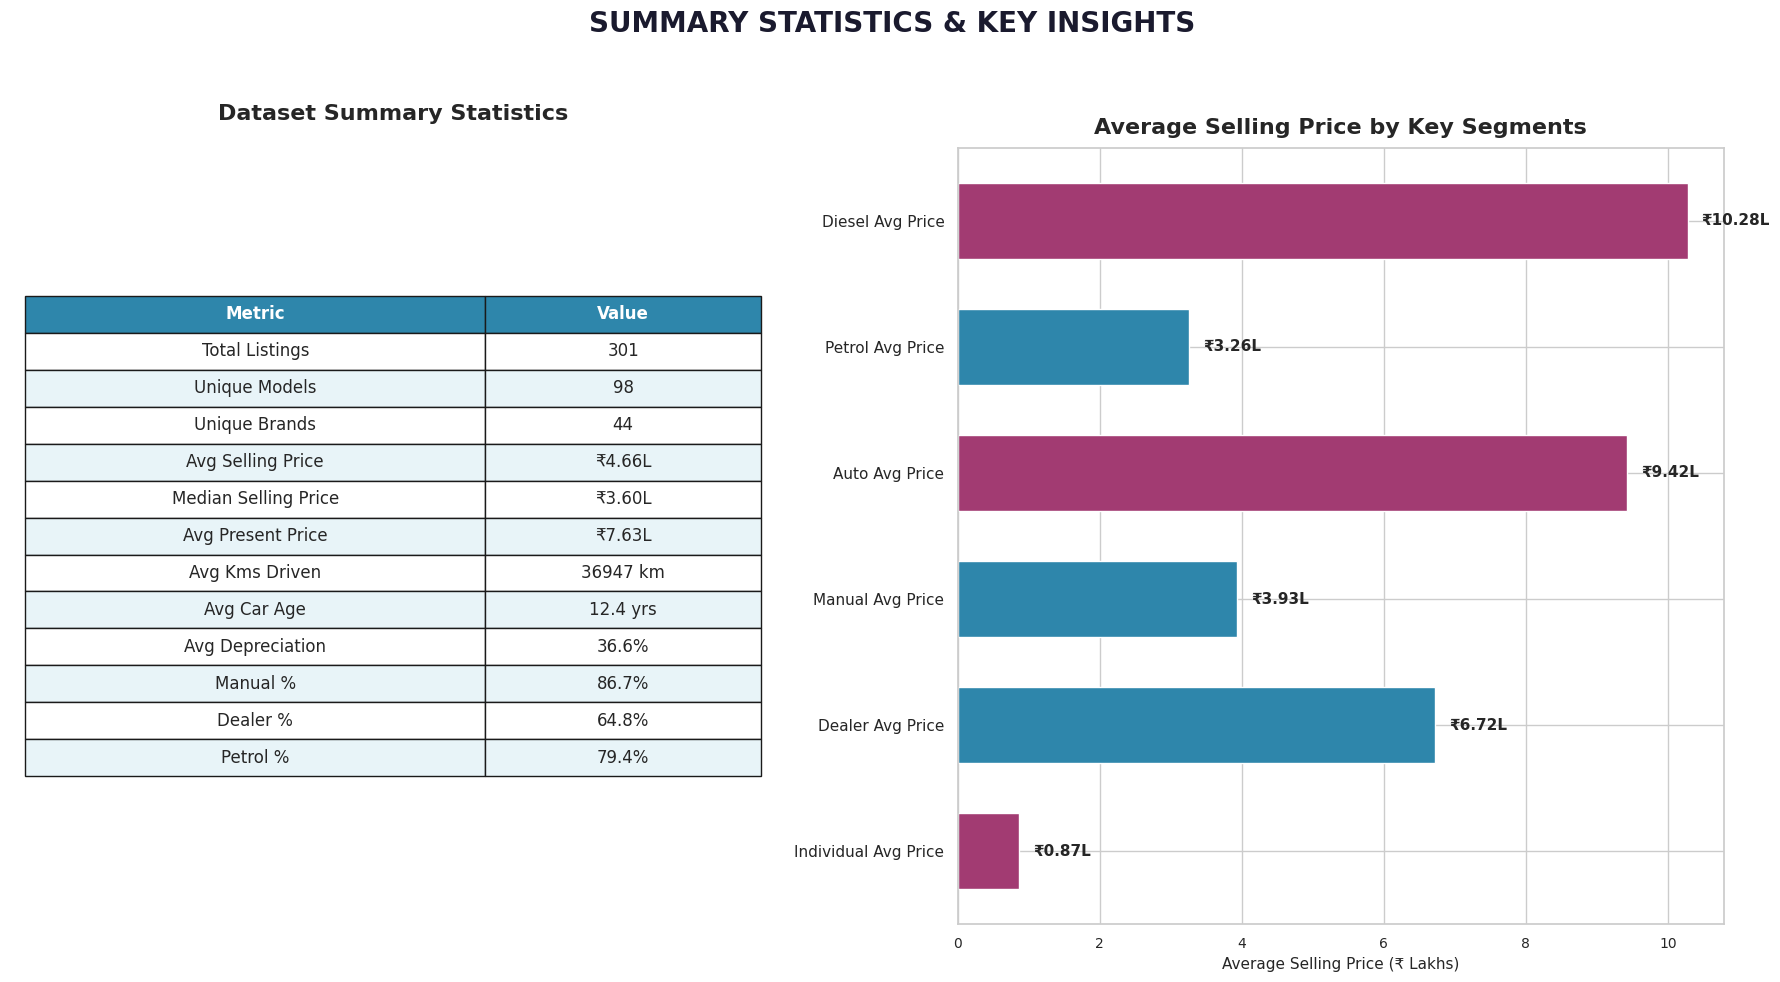

In [22]:


# CHART: SUMMARY STATISTICS TABLE & FINAL INSIGHTS

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('SUMMARY STATISTICS & KEY INSIGHTS', fontsize=20, fontweight='bold', y=0.98, color='#1a1a2e')

# 1. Comprehensive Summary Table
summary_stats = pd.DataFrame({
    'Metric': ['Total Listings', 'Unique Models', 'Unique Brands', 'Avg Selling Price', 'Median Selling Price',
               'Avg Present Price', 'Avg Kms Driven', 'Avg Car Age', 'Avg Depreciation', 'Manual %', 'Dealer %', 'Petrol %'],
    'Value': [f"{len(df)}", f"{df['Car_Name'].nunique()}", f"{df['Brand'].nunique()}",
              f"₹{df['Selling_Price'].mean():.2f}L", f"₹{df['Selling_Price'].median():.2f}L",
              f"₹{df['Present_Price'].mean():.2f}L", f"{df['Kms_Driven'].mean():.0f} km",
              f"{df['Car_Age'].mean():.1f} yrs", f"{df['Depreciation_Rate'].mean():.1f}%",
              f"{(df['Transmission']=='Manual').mean()*100:.1f}%",
              f"{(df['Seller_Type']=='Dealer').mean()*100:.1f}%",
              f"{(df['Fuel_Type']=='Petrol').mean()*100:.1f}%"]
})

axes[0].axis('off')
table = axes[0].table(cellText=summary_stats.values, colLabels=summary_stats.columns,
                       cellLoc='center', loc='center', colColours=['#2E86AB']*2,
                       colWidths=[0.5, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.2)
for i in range(len(summary_stats.columns)):
    table[(0, i)].set_text_props(color='white', fontweight='bold')
    table[(0, i)].set_facecolor('#2E86AB')
for i in range(1, len(summary_stats)+1):
    for j in range(2):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E8F4F8')
        else:
            table[(i, j)].set_facecolor('#FFFFFF')
axes[0].set_title('Dataset Summary Statistics', fontweight='bold', fontsize=16, pad=20)

# 2. Key Insights Bar Chart
insights = {
    'Diesel Avg Price': df[df['Fuel_Type']=='Diesel']['Selling_Price'].mean(),
    'Petrol Avg Price': df[df['Fuel_Type']=='Petrol']['Selling_Price'].mean(),
    'Auto Avg Price': df[df['Transmission']=='Automatic']['Selling_Price'].mean(),
    'Manual Avg Price': df[df['Transmission']=='Manual']['Selling_Price'].mean(),
    'Dealer Avg Price': df[df['Seller_Type']=='Dealer']['Selling_Price'].mean(),
    'Individual Avg Price': df[df['Seller_Type']=='Individual']['Selling_Price'].mean(),
}
colors_insight = ['#A23B72', '#2E86AB', '#A23B72', '#2E86AB', '#2E86AB', '#A23B72']
bars = axes[1].barh(range(len(insights)), list(insights.values()), color=colors_insight, edgecolor='white', height=0.6)
axes[1].set_yticks(range(len(insights)))
axes[1].set_yticklabels(list(insights.keys()), fontsize=11)
axes[1].invert_yaxis()
axes[1].set_title('Average Selling Price by Key Segments', fontweight='bold', fontsize=16, pad=10)
axes[1].set_xlabel('Average Selling Price (₹ Lakhs)')
for bar, val in zip(bars, insights.values()):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2, f'₹{val:.2f}L',
                 va='center', fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('/mnt/agents/output/07_summary_insights.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Chart saved: Summary & Insights")
